### Exploring Data

## 📚 Phase 0.1: Core Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
from tqdm import tqdm
from datetime import datetime

In [3]:
warnings.filterwarnings('ignore')

# Output directory for saving models and artifacts
os.makedirs('/kaggle/working/ridewise_artifacts', exist_ok=True)
ARTIFACT_DIR = '/kaggle/working/ridewise_artifacts'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports done | Device: {device}')

✅ Imports done | Device: cuda


## 📊 Phase 2: Data Loading & Understanding

In [5]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/uber-fares-dataset/uber.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (200000, 9)
Columns: ['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [6]:
print('=== Basic Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Fare Distribution ===')
print(df['fare_amount'].describe())

=== Basic Info ===
Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

=== Missing Values ===
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

=== Fare Distribution ===
count    200000.000000
mean         11.359955
std           9.901776
min         -52.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64


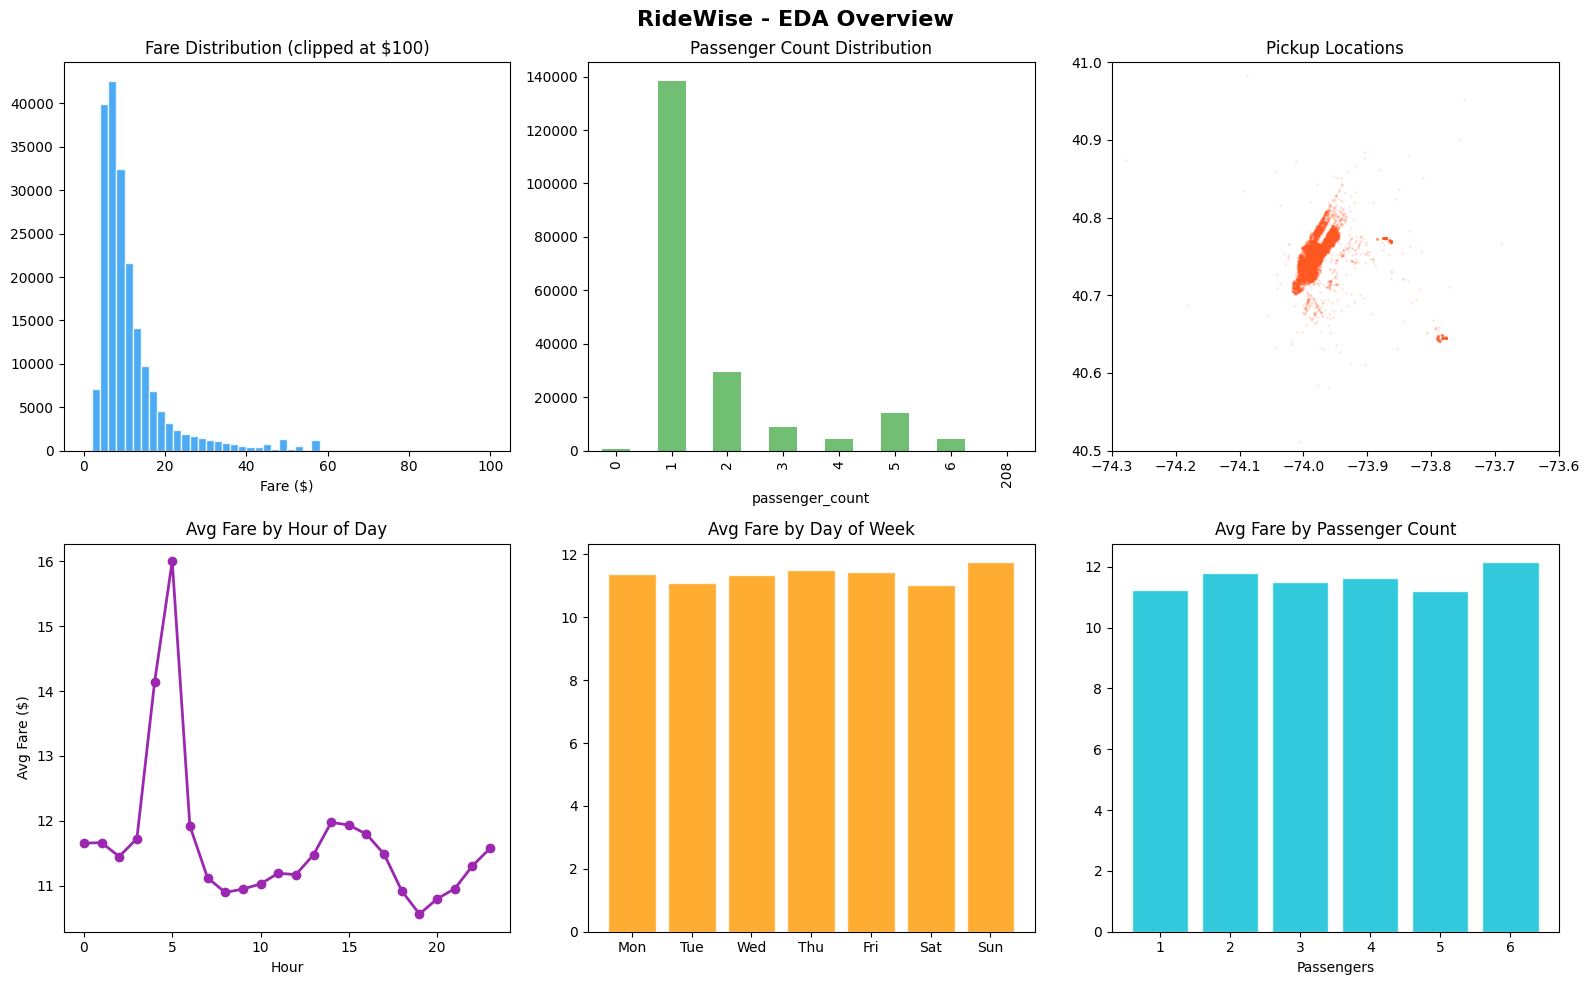

✅ EDA complete


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('RideWise - EDA Overview', fontsize=16, fontweight='bold')

# Fare distribution
axes[0,0].hist(df['fare_amount'].clip(0, 100), bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Fare Distribution (clipped at $100)')
axes[0,0].set_xlabel('Fare ($)')

# Passenger count
df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='#4CAF50', alpha=0.8)
axes[0,1].set_title('Passenger Count Distribution')

# Pickup coordinates scatter
sample = df.dropna().sample(min(10000, len(df)), random_state=42)
axes[0,2].scatter(sample['pickup_longitude'], sample['pickup_latitude'], 
                  alpha=0.1, s=1, c='#FF5722')
axes[0,2].set_title('Pickup Locations')
axes[0,2].set_xlim(-74.3, -73.6)
axes[0,2].set_ylim(40.5, 41.0)

# Fare vs time (parse pickup_datetime)
df_time = df.copy()
df_time['pickup_datetime'] = pd.to_datetime(df_time['pickup_datetime'], utc=True)
df_time['hour'] = df_time['pickup_datetime'].dt.hour
hourly_fare = df_time.groupby('hour')['fare_amount'].mean()
axes[1,0].plot(hourly_fare.index, hourly_fare.values, marker='o', color='#9C27B0', linewidth=2)
axes[1,0].set_title('Avg Fare by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Avg Fare ($)')

# Day of week
df_time['dayofweek'] = df_time['pickup_datetime'].dt.dayofweek
daily_fare = df_time.groupby('dayofweek')['fare_amount'].mean()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1,1].bar(days, daily_fare.values, color='#FF9800', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Avg Fare by Day of Week')

# Fare vs passenger count
pc_fare = df_time[df_time['passenger_count'].between(1,6)].groupby('passenger_count')['fare_amount'].mean()
axes[1,2].bar(pc_fare.index, pc_fare.values, color='#00BCD4', alpha=0.8, edgecolor='white')
axes[1,2].set_title('Avg Fare by Passenger Count')
axes[1,2].set_xlabel('Passengers')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA complete')